In [ ]:


def MakeVertices(self):
    """
    Generates the coordinates of the vertices, edges, and faces of a pentagonal bipyramid.
    Returns:
        - CoordVertices (np.ndarray): the 7 vertex coordinates of a pentagonal dipyramid
        - edges (np.ndarray): indexes of the 2x5 "vertical" edges of the pentagonal cap of an elongated pentagonal bipyramid
        - faces (np.ndarray): indexes of the 10 triangular faces
    """
    phi = self.phi
    scale = self.Rnn/2
    CoordVertices = [pyNMBu.vertexScaled(0,0,self.sizeE*self.magicFactorF+self.sizeP*np.sqrt((10-2*np.sqrt(5))/5),scale),
                     pyNMBu.vertexScaled(self.sizeP*np.sqrt((10+2*np.sqrt(5))/5),0,self.sizeE*self.magicFactorF,scale),
                     pyNMBu.vertexScaled(self.sizeP*np.sqrt((5-np.sqrt(5))/10),self.sizeP*phi,self.sizeE*self.magicFactorF,scale),
                     pyNMBu.vertexScaled(self.sizeP*-np.sqrt((5+2*np.sqrt(5))/5),self.sizeP,self.sizeE*self.magicFactorF,scale),
                     pyNMBu.vertexScaled(self.sizeP*-np.sqrt((5+2*np.sqrt(5))/5),-self.sizeP,self.sizeE*self.magicFactorF,scale),
                     pyNMBu.vertexScaled(self.sizeP*np.sqrt((5-np.sqrt(5))/10),-self.sizeP*phi,self.sizeE*self.magicFactorF,scale),
                    ]
    edgesPentagonalCap = [( 0, 1), ( 0, 2), ( 0, 3), ( 0, 4), ( 0, 5), (1, 2), (2, 3), (3, 4), (4, 5), (5, 1)]
    faces3 = [( 0, 1, 2), ( 0, 2, 3), ( 0, 3, 4), ( 0, 4, 5), ( 0, 5, 1)]

    CoordVertices = np.array(CoordVertices)
    edgesPentagonalCap = np.array(edgesPentagonalCap)
    faces3 = np.array(faces3)
    return CoordVertices, edgesPentagonalCap, faces3

def truncationPlaneTuples4MarksDecahedron(self,refPlaneAtoms,debug=False):
    '''
    This function calculates the truncation planes for the Marks decahedron nanoparticle shape. 
    It defines planes that truncate the vertices of the decahedron.

    Args:
        refPlaneAtoms (list): A list of three atoms coordinates that define a reference plane. 
        The list should contain:
        - summit atom (topmost point)
        - apex atom (the second point)
        - origin atom (used as reference)
        debug (bool): flag to enable or disable debugging information (default is False).
        
    Returns:
        planes (array-like): An array of 5 planes used for truncation, each defined by a normal vector and an offset.
        indicesOfTruncationPlanes (list): A list of tuples, each containing two indices that define the truncation plane pairs.
        '''

    # Fit a plane through the three reference atoms (summit, apex, origin)
    pRef = pyNMBu.planeFittingLSF(refPlaneAtoms,printEq=False,printErrors=False)
    pRef = pRef[0:3]
    O = refPlaneAtoms[2]
    apexC = refPlaneAtoms[1]

    # Calculate the distance between planes based on inter-atomic spacing
    interPlanarDistance = self.interCompactPlanesDistance
    d = -interPlanarDistance * (self.nAtomsPerEdgeOfPC-self.Marks-1)
    # Initialize the first plane using the fitted plane and calculated distance
    plane0 = np.append(pRef,[d])
    planes = [plane0]

    # Generate the next 4 planes by rotating the base plane around the z-axis by 72° intervals
    for i in range(1,5):
        angle = i*72
        x = pyNMBu.RotationMol(pRef,angle,'z')
        x = np.append(x,[d])
        planes.append(x)
        norm = pyNMBu.normV(x)
        if (debug): print("angle = ",angle,"  plane = ",x,"   norm = ",norm)
    planes = np.array(planes)
    if (debug): print("\nplanes:\n",planes)

    # Define the indices of the pairs of truncation plane
    indices = [0, 1, 2, 3, 4, 0, 1]
    indicesOfTruncationPlanes = []

    # Generate the pairs of truncation planes using the indices
    for i in range(0,5):
        tuple = (indices[i],indices[i+2])
        indicesOfTruncationPlanes.append(tuple)
    if (debug): print("\nIndices of couples of truncation planes:\n",indicesOfTruncationPlanes)
    # Return the planes and their respective index pairs for truncation
    return planes, indicesOfTruncationPlanes

def coords(self,noOutput):
    '''
    This function generates the coordinates of all atoms in the nanoparticle structure, 
    including the vertices, edges, faces, and internal atoms. It applies truncation 
    and symmetry operations where necessary to define the final geometry of the nanoparticle.

    Arguments:
        noOutput (bool): if True, suppresses output messages during execution.

    Returns:
        None. The function updates the class attributes directly, including the final atom positions.
    '''
    if not noOutput: vID.centertxt("Generation of coordinates",bgc='#007a7a',size='14',weight='bold')
    chrono = pyNMBu.timer(); chrono.chrono_start()
    c = [] # List of atom coordinates
    # print(self.nAtomsPerLayer)
    indexVertexAtoms = []
    indexEdgePCAtoms = []
    indexEdgeEPAtoms = []
    indexFace3Atoms = []
    indexCoreAtoms = []

    # Generate vertices
    nAtoms0 = 0
    self.nAtoms = 6
    cVertices, E, F3 = self.MakeVertices()
    c.extend(cVertices.tolist())
    indexVertexAtoms.extend(range(nAtoms0,self.nAtoms))
    
    # Generate atoms on the edges of the nanoparticle
    nAtoms0 = self.nAtoms
    Rvv = pyNMBu.RAB(cVertices,E[0,0],E[0,1]) # Distance between two vertex atoms
    nAtomsOnEdges = int((Rvv+1e-6) / self.Rnn) - 1
    nIntervals = nAtomsOnEdges + 1
    coordEdgeAt = []
    for n in range(nAtomsOnEdges):
        for e in E:
            a = e[0]
            b = e[1]
            tmp = cVertices[a]+pyNMBu.vector(cVertices,a,b)*(n+1) / nIntervals
            coordEdgeAt.append(tmp)
    self.nAtoms += nAtomsOnEdges * len(E)
    c.extend(coordEdgeAt)
    # CAtoms.extend(range(nAtoms0,self.nAtoms))
    self.nAtomsPerEdgeOfPC = nAtomsOnEdges  + 2 #2 vertices
    
    # Generate triangular facets atoms
    coordFace3At = []
    nAtomsOnFaces3 = 0
    nAtoms0 = self.nAtoms
    for f in F3:
        nAtomsOnFaces3,coordFace3At = pyNMBu.MakeFaceCoord(self.Rnn,f,c,nAtomsOnFaces3,coordFace3At)
    self.nAtoms += nAtomsOnFaces3
    c.extend(coordFace3At)
    indexFace3Atoms.extend(range(nAtoms0,self.nAtoms))
    
    # Apply truncation if the Marks decahedron is being used
    if self.Marks != 0:
        pMarks, indexCouples = self.truncationPlaneTuples4MarksDecahedron(np.array([c[0],c[1],[0,0,0]]))
        for ic in indexCouples: # Apply truncation planes to remove atoms above them
            p0 = pMarks[ic[0]].copy()
            p1 = pMarks[ic[1]].copy()
            p1[0:3] = -p1[0:3] # don't forget to change the sign, see scheme in Sandbox 
            planes = [p0, p1]
            AtomsAboveAllPlanes = pyNMBu.truncateAbovePlanes(planes,c,allP=True,delAbove=True,debug=False,noOutput=noOutput)
            c = pyNMBu.deleteElementsOfAList(c,AtomsAboveAllPlanes)
            self.nAtoms = len(c)
    
    # Reflection of the upper pyramid w.r.t. the (0,0,1) plane
    symPlane = np.array([0,0,1,0])
    ReflectionAtoms = pyNMBu.reflection(symPlane,c,True)
    c.extend(ReflectionAtoms)
    self.nAtoms += len(ReflectionAtoms)

    # Generate internal atoms (core atoms)
    nAtomsHalfPy = int(self.nAtoms/2)
    coordCoreAt = []
    for i in range(nAtomsHalfPy):
        Rvv = pyNMBu.RAB(c,i,i+nAtomsHalfPy) #distance between two mirror atoms
        nAtomsInCore = int((Rvv+1e-6) / self.Rnn*self.magicFactorF) - 1
        nIntervals = nAtomsInCore + 1
        for n in range(nAtomsInCore):
            tmp = c[i]+pyNMBu.vector(c,i,i+nAtomsHalfPy)*(n+1) / nIntervals
            coordCoreAt.append(tmp)
    self.nAtoms += len(coordCoreAt)
    c.extend(coordCoreAt)
    # if self.sizeE = 0, it's a pentagonal bipyramid or a Marks decahedron without side faces
    # given the doItForAtomsThatLieInTheReflectionPlane trick in pyNMBu.reflection, it is necessary to remove duplicate atoms
    if self.sizeE == 0:
        c = np.unique(np.array(c),axis=0)
        self.nAtoms = len(c)

    aseObject = ase.Atoms(self.element*self.nAtoms, positions=c)

    if not noOutput: print(f"Total number of atoms = {self.nAtoms}")
    if not noOutput: chrono.chrono_stop(hdelay=False); chrono.chrono_show()
    self.NP = aseObject
    self.cog = self.NP.get_center_of_mass()



In [5]:
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
import numpy as np

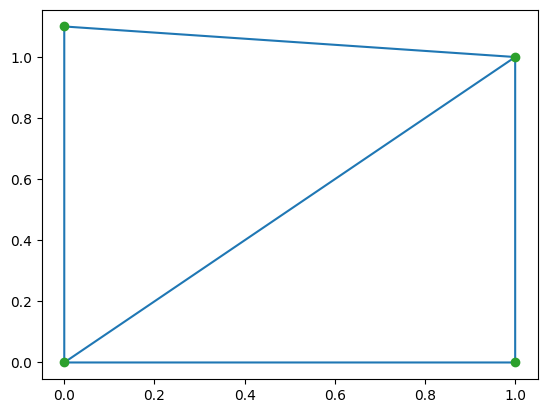

In [6]:
points = np.array([[0, 0], [0, 1.1], [1, 0], [1, 1]])

tri = Delaunay(points)



plt.triplot(points[:,0], points[:,1], tri.simplices.copy())
plt.plot(points[:,0], points[:,1], 'o')
plt.show()
